# Determining the number of nuclei

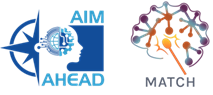

**Objective** <br>
Segment and quantify nuclei in microscopy images by applying Otsu thresholding to obtain a binary mask, identifying connected components to estimate object count, and using contour detection to outline individual nuclei



**Relevant resources** <br>
[OpenCV: Image Thresholding](https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html) <br>
[OpenCV: Contours : Getting Started](https://docs.opencv.org/3.4/d4/d73/tutorial_py_contours_begin.html) <br>
[OpenCV: Connected Components Function](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gac2718a64ade63475425558aa669a943a) <br>
[OpenCV: Contour Features](https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html)

**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Computer vision for microscopy image analysis. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenters: David Hernandez-Guzman and Mignon Dumanjog, University of Texas at San Antonio<br> Code Author: Mignon Dumanjog, University of Texas at San Antonio<br>



---



# Import packages


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import urllib.request

# Load images
Use either option 1 or option 2.

**Option 1:** Access the photos through GitHub links (no downloads necessary)

In [ ]:
# Import images
img_A_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellA_Nuclei.jpg'
img_B_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellB_Nuclei.jpg'
img_C_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellC_Nuclei.jpg'

def load_image_from_url(url):
    with urllib.request.urlopen(url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

A = load_image_from_url(img_A_path)
B = load_image_from_url(img_B_path)
C = load_image_from_url(img_C_path)

# Check if images were loaded successfully
images_to_check = {'A': A, 'B': B, 'C': C}
image_paths = {'A': img_A_path, 'B': img_B_path, 'C': img_C_path}

for img_name, img_data in images_to_check.items():
    if img_data is None:
        raise FileNotFoundError(f"Error: Could not load image from {image_paths[img_name]}. Please ensure the file exists and the path is correct.")
    else:
        print(f"Image {img_name} loaded successfully.")

Image A loaded successfully.
Image B loaded successfully.
Image C loaded successfully.


**Option 2:** Locally or through Google drive

In [ ]:
# # Uncomment if accessing images via Google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import images
img_A_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellA_Nuclei.jpg' # update with your file path
img_B_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellB_Nuclei.jpg' # update with your file path
img_C_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellC_Nuclei.jpg' # update with your file path

A = cv2.imread(img_A_path)
B = cv2.imread(img_B_path)
C = cv2.imread(img_C_path)

# Check if images were loaded successfully
images_to_check = {'A': A, 'B': B, 'C': C}
image_paths = {'A': img_A_path, 'B': img_B_path, 'C': img_C_path}

for img_name, img_data in images_to_check.items():
    if img_data is None:
        raise FileNotFoundError(f"Error: Could not load image from {image_paths[img_name]}. Please ensure the file exists and the path is correct.")
    else:
        print(f"Image {img_name} loaded successfully.")

**Once loaded, display the images**

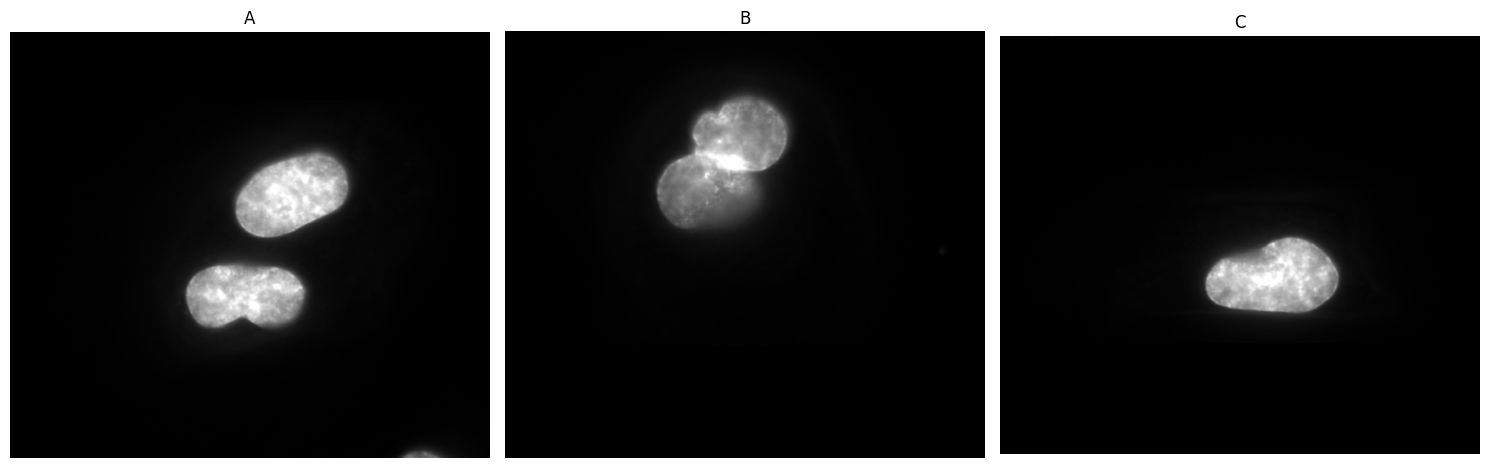

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(A)
plt.title('A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B)
plt.title('B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(C)
plt.title('C')
plt.axis('off')

plt.tight_layout()
plt.show()

# Apply grayscaling + blurring filter

Blurring is applied before contour detection to reduce noise and small intensity variations, producing smoother, more accurate contours.


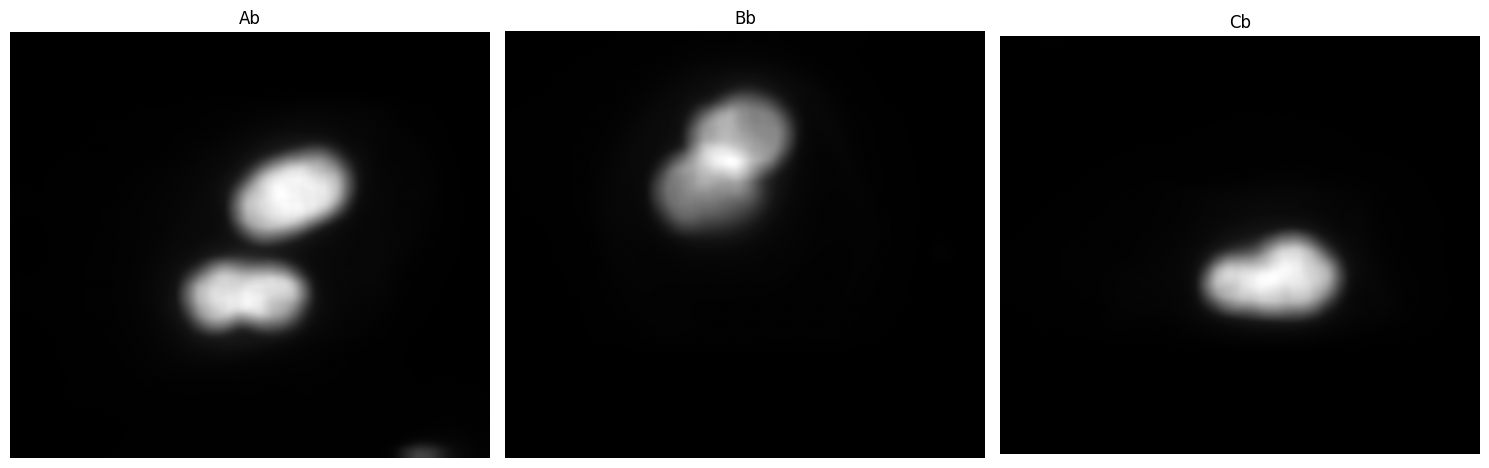

In [ ]:
# Grayscale and blur
Ab = cv2.blur(cv2.cvtColor(A,cv2.COLOR_BGR2GRAY), (50,50))
Bb = cv2.blur(cv2.cvtColor(B,cv2.COLOR_BGR2GRAY), (50,50))
Cb = cv2.blur(cv2.cvtColor(C,cv2.COLOR_BGR2GRAY), (50,50))

# Display grayscale blurred images Ab, Bb, and Cb
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Ab, cmap='gray')
plt.title('Ab')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Bb, cmap='gray')
plt.title('Bb')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Cb, cmap='gray')
plt.title('Cb')
plt.axis('off')

plt.tight_layout()
plt.show()

# Otsu's thresholding
A global threshold that best separates foreground and background is automatically selected by minimizing intra-class variance (or equivalently maximizing between-class variance).

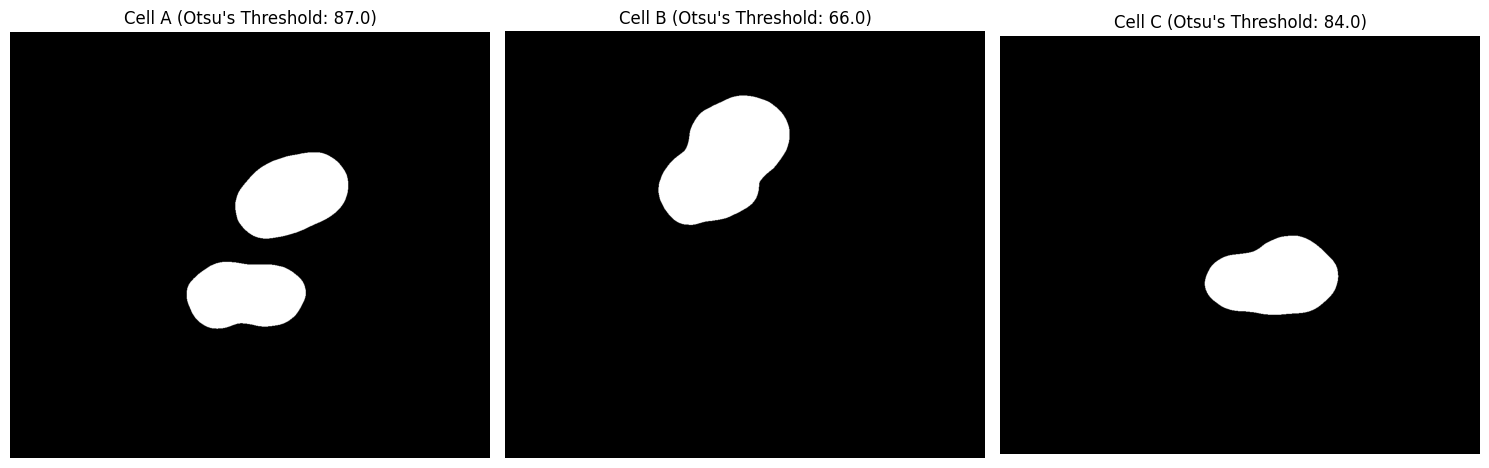

In [ ]:
# Otsu's Thresholding
ret_A, thresh_A = cv2.threshold(Ab, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ret_B, thresh_B = cv2.threshold(Bb, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ret_C, thresh_C = cv2.threshold(Cb, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresh_A, cmap='gray')
plt.title("Cell A (Otsu's Threshold: " + str(round(ret_A, 2)) + ")")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_B, cmap='gray')
plt.title("Cell B (Otsu's Threshold: " + str(round(ret_B, 2)) + ")")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_C, cmap='gray')
plt.title("Cell C (Otsu's Threshold: " + str(round(ret_C, 2)) + ")")
plt.axis('off')

plt.tight_layout()
plt.show()

# Obtain number of nuclei and display bounding boxes

We identify nuclei by detecting **connected components**—clusters of adjacent foreground pixels in a binary image treated as individual objects.


Number of connected components: 3
Component 0: bbox=(0,0,1097,973), area=996225, centroid=(544.8,486.4)
Component 1: bbox=(515,275,258,197), area=37540, centroid=(642.9,372.0)
Component 2: bbox=(404,525,272,153), area=33616, centroid=(537.3,600.7)


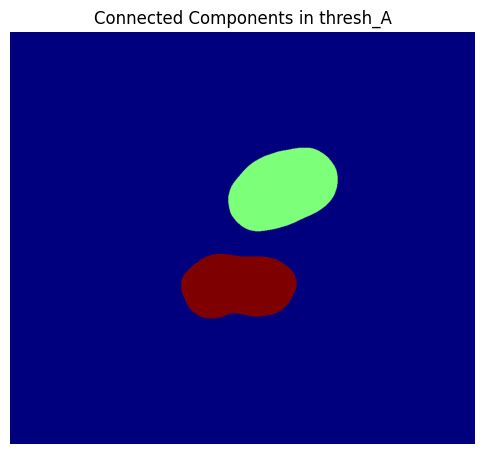

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh_A)

print(f"Number of connected components: {num_labels}")

# stats: [label, x, y, width, height, area]
for i in range(0, num_labels):
    x, y, w, h, area = stats[i]
    cx, cy = centroids[i]
    print(f"Component {i}: bbox=({x},{y},{w},{h}), area={area}, centroid=({cx:.1f},{cy:.1f})")

# Display connected components in thresh_A
plt.figure(figsize=(6, 6))
plt.imshow(labels, cmap='jet')
plt.title("Connected Components in thresh_A")
plt.axis('off')
plt.show()

Each component is represented with a **bounding box**, a rectangle that tightly encloses it, providing a clear way to locate and visualize the nuclei. Loop over all three images and display bounding boxes around cells

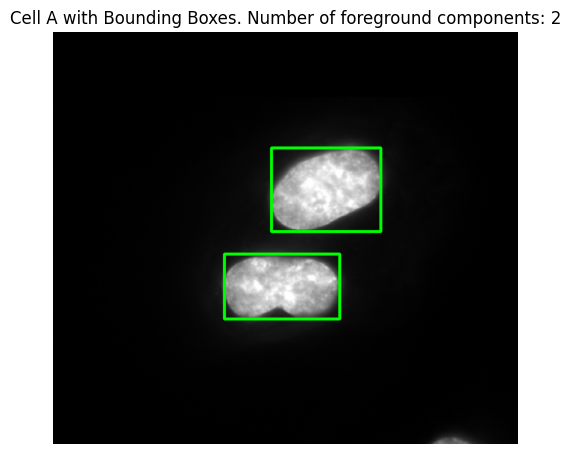

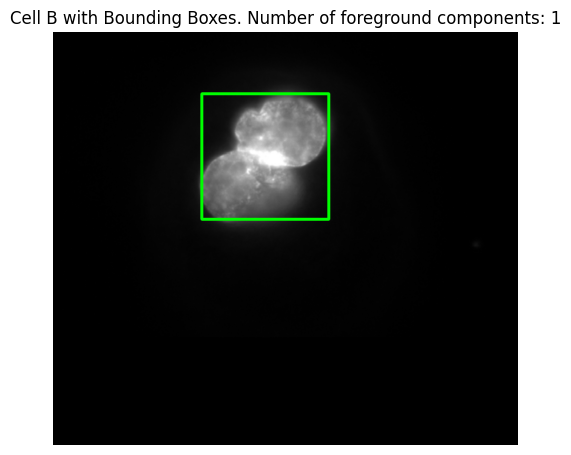

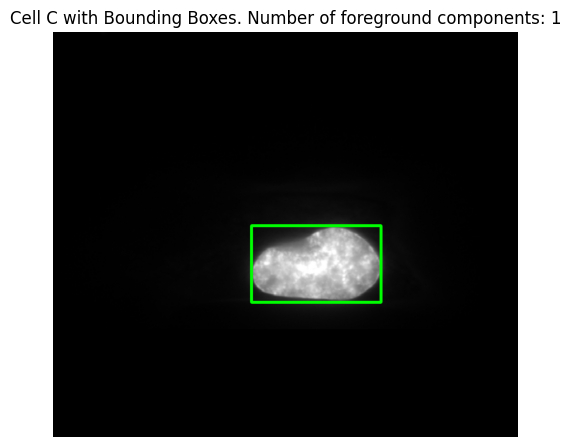

In [ ]:
images = {"A": thresh_A, "B": thresh_B, "C": thresh_C}
main_images = {"A": A.copy(), "B": B.copy(), "C": C.copy()}

for name, img in images.items():
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img)

    img_bbox = main_images[name]
    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (0, 255, 0), 5)

    plt.figure(figsize=(6,6))
    plt.imshow(img_bbox)
    plt.title(f"Cell {name} with Bounding Boxes. Number of foreground components: {num_labels-1}")
    plt.axis('off')
    plt.show()

# Define contours

We could also outline and obtain the contour objects for each cell, as in the previous exercise.

In [ ]:
def find_contours(thresh_img):
    contours, hierarchy = cv2.findContours(thresh_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    nuclei_count = len(contours)
    return contours, nuclei_count

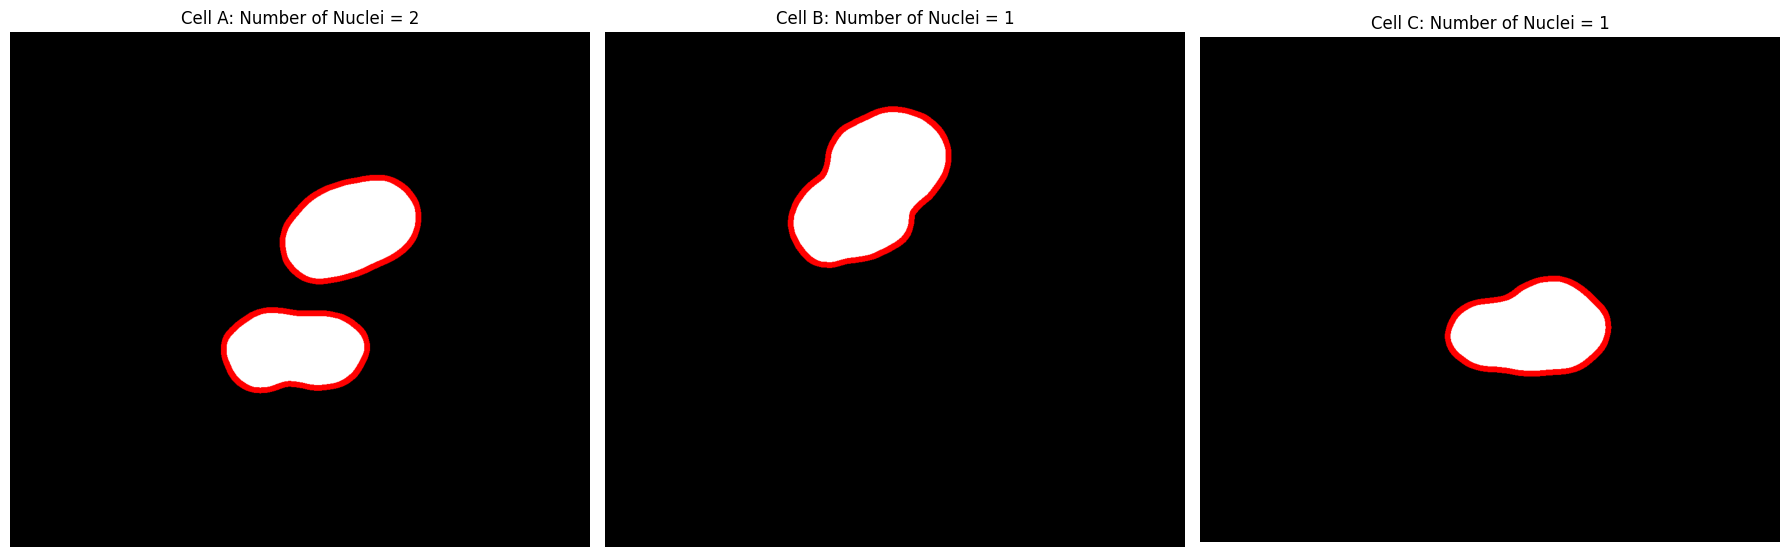

In [ ]:
# Apply function
contours_A, A_nuc = find_contours(thresh_A)
contours_B, B_nuc = find_contours(thresh_B)
contours_C, C_nuc = find_contours(thresh_C)

# Draw all contours
con_A = cv2.drawContours(cv2.cvtColor(thresh_A.copy(), cv2.COLOR_GRAY2RGB), contours_A, -1, (255, 0, 0), 10)
con_B = cv2.drawContours(cv2.cvtColor(thresh_B.copy(), cv2.COLOR_GRAY2RGB), contours_B, -1, (255, 0, 0), 10)
con_C = cv2.drawContours(cv2.cvtColor(thresh_C.copy(), cv2.COLOR_GRAY2RGB), contours_C, -1, (255, 0, 0), 10)

# Display all contours
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(con_A)
plt.title("Cell A: Number of Nuclei = "+str(A_nuc))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(con_B)
plt.title("Cell B: Number of Nuclei = "+str(B_nuc))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(con_C)
plt.title("Cell C: Number of Nuclei = "+str(C_nuc))
plt.axis('off')

plt.tight_layout()
plt.show()